<a href="https://colab.research.google.com/github/kesavsabari/AI-Text-Detector/blob/main/AI_Text_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AI Generated vs Human Written Essay Classifier


#Data Analysis and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import sklearn.model_selection
import sklearn.feature_extraction.text
import sklearn.linear_model
import sklearn.metrics

##Defining Business Problem

Binary classification - predict if an essay is human written (0) or AI generated (1).

Dataset: https://www.kaggle.com/datasets/thedrcat/daigt-v2-train-dataset

##Data Collection

In [2]:
df = pd.read_csv("data/daigt_v3.csv")
df.head()

,text,label,prompt_name,source,RDizzl3_seven
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,False
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,False
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,False
3,Phones & Driving\n\nDrivers should not be able...,0,Phones and driving,persuade_corpus,False
4,Cell Phone Operation While Driving\n\nThe abil...,0,Phones and driving,persuade_corpus,False


In [3]:
df.shape

(65508, 5)

##Data Exploration

###Data Types

In [4]:
df.dtypes

text               str
label            int64
prompt_name        str
source             str
RDizzl3_seven     bool
dtype: object

In [5]:
df.isnull().sum()

text             148
label              0
prompt_name        0
source             0
RDizzl3_seven      0
dtype: int64

###Visualisation

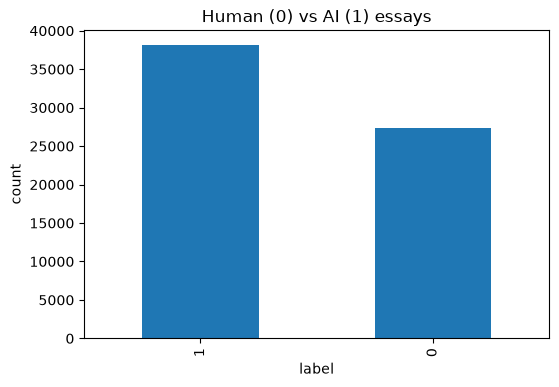

In [6]:
df['label'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Human (0) vs AI (1) essays")
plt.xlabel("label")
plt.ylabel("count")
plt.show()

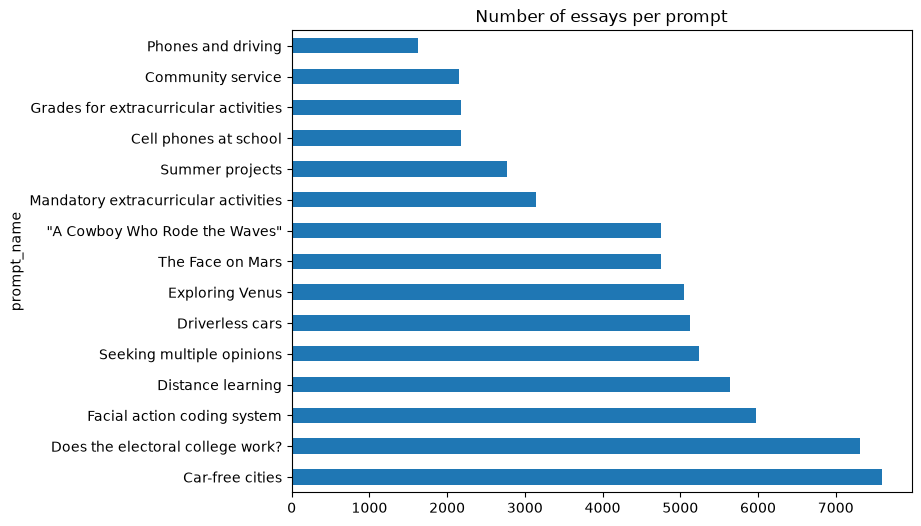

In [7]:
df['prompt_name'].value_counts().plot(kind='barh', figsize=(8,6))
plt.title("Number of essays per prompt")
plt.show()

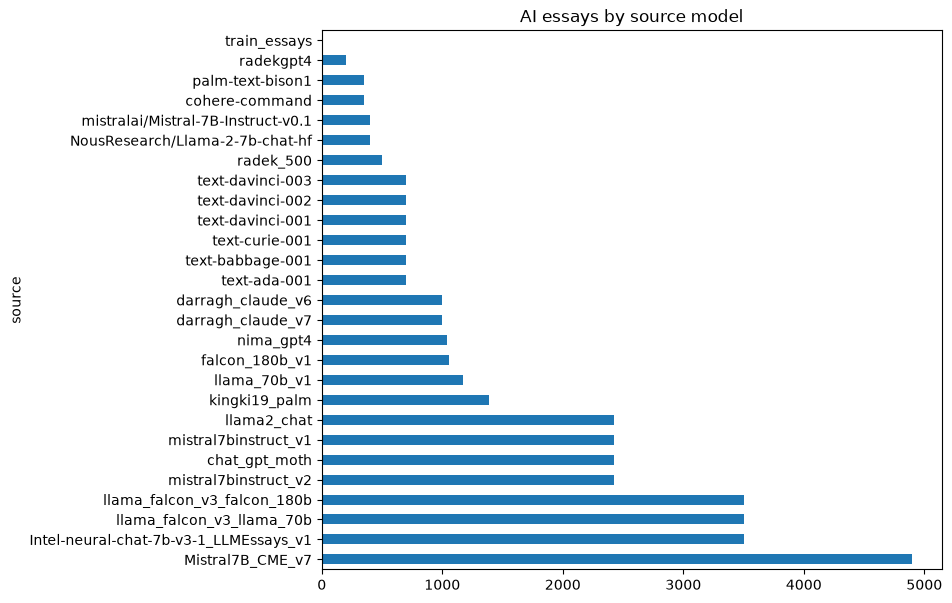

In [8]:
df[df['label']==1]['source'].value_counts().plot(kind='barh', figsize=(8,7))
plt.title("AI essays by source model")
plt.show()

In [9]:
df['length'] = df['text'].str.len()
df.groupby('label')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,27371.0,2348.503891,1124.489852,691.0,1499.5,2132.0,2929.0,18322.0
1,37989.0,2373.560978,1032.486256,1.0,1742.0,2218.0,2781.0,8871.0


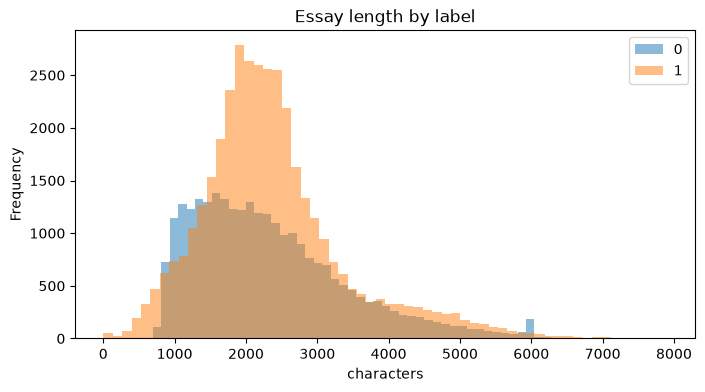

In [10]:
df[df['length'] < 8000].groupby('label')['length'].plot(kind='hist', bins=60, alpha=0.5, legend=True, figsize=(8,4))
plt.title("Essay length by label")
plt.xlabel("characters")
plt.show()

##Data Cleaning

In [11]:
df = df.dropna(subset=['text'])
df = df[df['length'] > 200]

df = df.drop_duplicates(subset=['text'])

def clean_text(t):
    t = t.replace("\n", " ")
    t = re.sub(r"\s+", " ", t)
    return t.strip()

df['text'] = df['text'].apply(clean_text)
df = df[['text', 'label', 'prompt_name', 'source']]
df.shape

(65293, 4)

##Train Test Split

In [12]:
splitter = sklearn.model_selection.GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df['prompt_name']))

df_train = df.iloc[train_idx]
df_test = df.iloc[test_idx]

print("train:", df_train.shape, " test:", df_test.shape)
print("test prompts:", list(df_test['prompt_name'].unique()))

train: (56749, 4)  test: (8544, 4)
test prompts: ['Phones and driving', '"A Cowboy Who Rode the Waves"', 'Grades for extracurricular activities']


In [13]:
df_train['label'].value_counts(normalize=True)

label
1    0.591094
0    0.408906
Name: proportion, dtype: float64

In [14]:
df_test['label'].value_counts(normalize=True)

label
1    0.512406
0    0.487594
Name: proportion, dtype: float64

#Model 1 - TF-IDF + Logistic Regression (baseline)

In [15]:
vectorizer = sklearn.feature_extraction.text.TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=200000, sublinear_tf=True)

X_train = vectorizer.fit_transform(df_train['text'])
X_test = vectorizer.transform(df_test['text'])
y_train = df_train['label']
y_test = df_test['label']

X_train.shape

(56749, 200000)

In [16]:
logreg = sklearn.linear_model.LogisticRegression(max_iter=1000, C=2)
logreg.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [17]:
pred_tfidf = logreg.predict(X_test)
prob_tfidf = logreg.predict_proba(X_test)[:,1]

print("accuracy:", sklearn.metrics.accuracy_score(y_test, pred_tfidf))
print("f1:", sklearn.metrics.f1_score(y_test, pred_tfidf))
print("roc auc:", sklearn.metrics.roc_auc_score(y_test, prob_tfidf))

accuracy: 0.9619616104868914
f1: 0.9634872486237501
roc auc: 0.9939905962843503


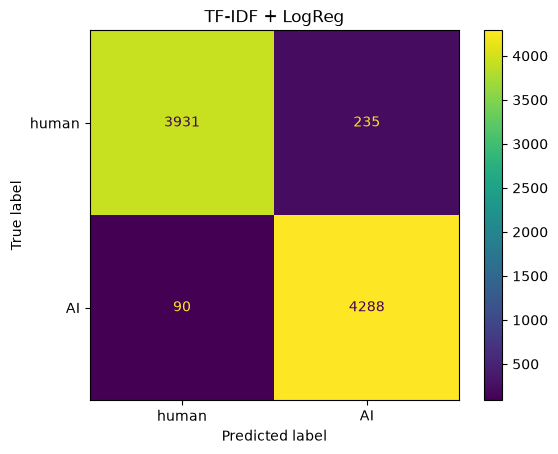

In [18]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred_tfidf, display_labels=['human','AI'])
plt.title("TF-IDF + LogReg")
plt.show()

In [19]:
print(sklearn.metrics.classification_report(y_test, pred_tfidf, target_names=['human','AI']))

              precision    recall  f1-score   support

       human       0.98      0.94      0.96      4166
          AI       0.95      0.98      0.96      4378

    accuracy                           0.96      8544
   macro avg       0.96      0.96      0.96      8544
weighted avg       0.96      0.96      0.96      8544



#Model 2 - DistilBERT fine tuning

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [21]:
TRAIN_SAMPLES = 8000
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 2
LR = 2e-5

df_small = df_train.groupby('label').sample(n=TRAIN_SAMPLES//2, random_state=42)
df_small = df_small.sample(frac=1, random_state=42)
df_small['label'].value_counts()

label
0    4000
1    4000
Name: count, dtype: int64

In [22]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

class EssayDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], truncation=True, max_length=MAX_LEN, padding='max_length', return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[i])
        }

train_loader = DataLoader(EssayDataset(df_small['text'], df_small['label']), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(EssayDataset(df_test['text'], df_test['label']), batch_size=64)

In [23]:
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for i, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = out.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if i % 100 == 0:
            print("epoch", epoch+1, "batch", i, "/", len(train_loader), "loss", round(loss.item(), 4))
    print("epoch", epoch+1, "avg loss =", round(total_loss/len(train_loader), 4))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


epoch 1 batch 0 / 500 loss 0.7144


epoch 1 batch 100 / 500 loss 0.0767


epoch 1 batch 200 / 500 loss 0.0495


epoch 1 batch 300 / 500 loss 0.0118


epoch 1 batch 400 / 500 loss 0.1349


epoch 1 avg loss = 0.1115


epoch 2 batch 0 / 500 loss 0.0039


epoch 2 batch 100 / 500 loss 0.0095


epoch 2 batch 200 / 500 loss 0.0063


epoch 2 batch 300 / 500 loss 0.0023


epoch 2 batch 400 / 500 loss 0.0022


epoch 2 avg loss = 0.0275


In [24]:
model.eval()
prob_bert = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        out = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(out.logits, dim=1)[:,1]
        prob_bert.extend(probs.cpu().numpy())

prob_bert = np.array(prob_bert)
pred_bert = (prob_bert > 0.5).astype(int)

print("accuracy:", sklearn.metrics.accuracy_score(y_test, pred_bert))
print("f1:", sklearn.metrics.f1_score(y_test, pred_bert))
print("roc auc:", sklearn.metrics.roc_auc_score(y_test, prob_bert))

accuracy: 0.9741338951310862
f1: 0.9751545812254075
roc auc: 0.996706298041949


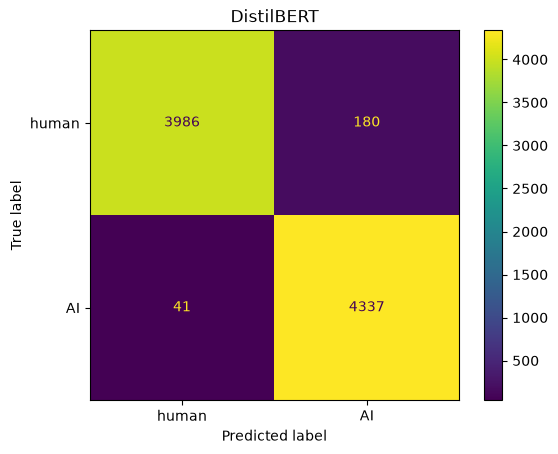

In [25]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred_bert, display_labels=['human','AI'])
plt.title("DistilBERT")
plt.show()

#Model Comparison

In [26]:
results = pd.DataFrame({
    'model': ['TF-IDF + LogReg', 'DistilBERT'],
    'accuracy': [sklearn.metrics.accuracy_score(y_test, pred_tfidf), sklearn.metrics.accuracy_score(y_test, pred_bert)],
    'f1': [sklearn.metrics.f1_score(y_test, pred_tfidf), sklearn.metrics.f1_score(y_test, pred_bert)],
    'roc_auc': [sklearn.metrics.roc_auc_score(y_test, prob_tfidf), sklearn.metrics.roc_auc_score(y_test, prob_bert)]
})
results

,model,accuracy,f1,roc_auc
0,TF-IDF + LogReg,0.961962,0.963487,0.993991
1,DistilBERT,0.974134,0.975155,0.996706


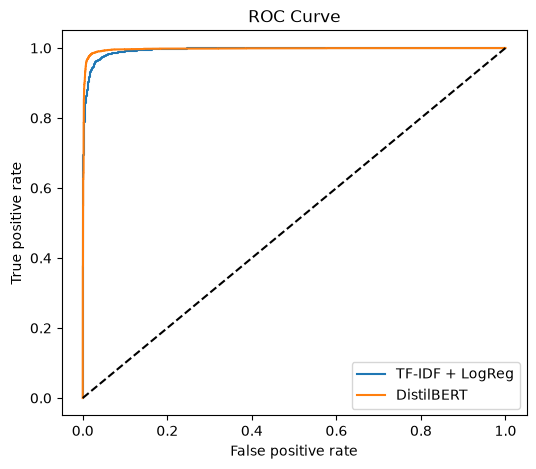

In [27]:
fpr1, tpr1, _ = sklearn.metrics.roc_curve(y_test, prob_tfidf)
fpr2, tpr2, _ = sklearn.metrics.roc_curve(y_test, prob_bert)
plt.figure(figsize=(6,5))
plt.plot(fpr1, tpr1, label='TF-IDF + LogReg')
plt.plot(fpr2, tpr2, label='DistilBERT')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

##Which AI models are hardest to detect?

In [28]:
df_test = df_test.copy()
df_test['pred_tfidf'] = pred_tfidf
df_test['pred_bert'] = pred_bert

ai_only = df_test[df_test['label'] == 1]

per_source = pd.DataFrame()
per_source['n'] = ai_only.groupby('source').size()
per_source['tfidf_detected'] = ai_only.groupby('source')['pred_tfidf'].mean()
per_source['bert_detected'] = ai_only.groupby('source')['pred_bert'].mean()
per_source = per_source.sort_values('bert_detected')
per_source

,n,tfidf_detected,bert_detected
source,,,
mistral7binstruct_v2,83,0.915663,0.939759
llama_70b_v1,271,0.948339,0.948339
text-ada-001,99,1.000000,0.969697
darragh_claude_v7,206,0.961165,0.970874
darragh_claude_v6,200,0.960000,0.980000
cohere-command,50,0.840000,0.980000
text-davinci-002,100,0.940000,0.980000
nima_gpt4,168,0.994048,0.988095
text-babbage-001,99,0.949495,0.989899


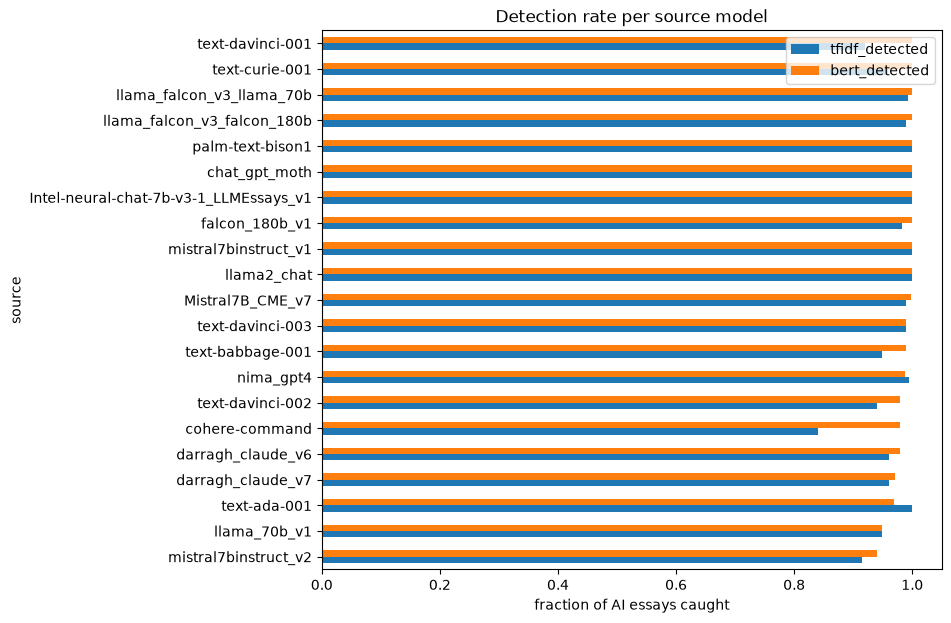

In [29]:
per_source[['tfidf_detected', 'bert_detected']].plot(kind='barh', figsize=(8,7))
plt.title("Detection rate per source model")
plt.xlabel("fraction of AI essays caught")
plt.show()

##Accuracy per prompt

In [30]:
df_test['correct_tfidf'] = (df_test['pred_tfidf'] == df_test['label'])
df_test['correct_bert'] = (df_test['pred_bert'] == df_test['label'])
df_test.groupby('prompt_name')[['correct_tfidf', 'correct_bert']].mean()

,correct_tfidf,correct_bert
prompt_name,,
"""A Cowboy Who Rode the Waves""",0.953518,0.983309
Grades for extracurricular activities,0.982569,0.989908
Phones and driving,0.958921,0.926426


##Looking at mistakes

In [31]:
wrong = df_test[(df_test['label'] == 0) & (df_test['pred_bert'] == 1)]
print(len(wrong), "human essays flagged as AI\n")
for t in wrong['text'].head(3):
    print(t[:300], "...\n")

180 human essays flagged as AI

People are debating whether if drivers should or should not use cell phones while operating a vehicle. Some people think that using a cell phone while operating a vehicle should be allowed because they try multi-tasking and have important calls while some are addicted and can't stay off their phone. ...

Should Drivers Be Allowed To Use Cell Phones When Driving? Why Driver's should desist from using their Cell Phones while DrivingHundreds of research indicate that using the cell phone while driving is a dangerous prospect that leads to loss of lives. Statistically, 50 minutes of phone chatter while  ...

Don't Touch the Screen As we drove to the final basketball game of the season against our rivals Milton High School, I was having a great time with my best friend. Paige and I were stopped at the intersection on Highway 9 when a white SUV crashed into the back of her Nissan Rogue. We were both rushe ...



#Conclusion

- Both models get ~96% accuracy on prompts they never saw during training, so they are learning writing style not topic.
- The simple TF-IDF baseline is almost as good as DistilBERT and trains in a minute on CPU, so for this dataset the deep model isnt really worth the extra compute.
- Older/smaller models (text-ada, text-curie, mistral7b) are slightly harder to catch than the big ones.
- Main false positives are human essays that are very formal and structured, which is what AI writing usually looks like.